In [142]:
import pyodbc
import pandas as pd
import numpy as np

print(pyodbc.drivers())

['SQL Server', 'SQL Server Native Client 11.0', 'B1CRHPROXY', 'ODBC Driver 13 for SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)', 'ODBC Driver 18 for SQL Server', 'SQL Server Native Client RDA 11.0', 'ODBC Driver 17 for SQL Server']


In [143]:
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus
from dotenv import load_dotenv
import os
import pyodbc

load_dotenv()

SERVER = os.getenv("DB_SERVER1")
DBNAME = os.getenv("DB_NAME1")
USER = os.getenv("DB_USER1")
PASS = os.getenv("DB_PASSWORD1")
ENCRYPT = os.getenv("DB_ENCRYPT", "yes")
TRUST = os.getenv("DB_TRUST_CERT", "yes")

SERVER = SERVER.replace("\\\\", "\\")  # normaliza


cnx = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    f"SERVER={SERVER};"
    f"DATABASE={DBNAME};"
    f"UID={USER};"
    f"PWD={PASS};"
    f"Encrypt={ENCRYPT};TrustServerCertificate={TRUST};"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={quote_plus(cnx)}")

In [144]:
from sqlalchemy import text
try:
    with engine.connect() as conn:
        print("Ping:", conn.execute(text("SELECT 1")).scalar_one())
        print("Version:", conn.execute(text("SELECT @@VERSION")).scalar_one())
        print("✅ Conexión OK")
except Exception as e:
    print("❌ Error al conectar:", e)

Ping: 1
Version: Microsoft SQL Server 2017 (RTM) - 14.0.1000.169 (X64) 
	Aug 22 2017 17:04:49 
	Copyright (C) 2017 Microsoft Corporation
	Standard Edition (64-bit) on Windows Server 2019 Standard 10.0 <X64> (Build 17763: )

✅ Conexión OK


In [145]:
import pandas as pd
# 🔥 TEST 2: traer datos a pandas
query = "SELECT TOP 10 * FROM OITM"

df = pd.read_sql(query, engine)

df.head(5)

,ItemCode,ItemName,FrgnName,ItmsGrpCod,CstGrpCode,VatGourpSa,CodeBars,VATLiable,PrchseItem,SellItem,...,U_CI_15_Familia,U_CI_16_CaMeHP,U_CI_16_Ratio,U_CI_16_DiEjeSal,U_CI_14_DiExtRoMM,U_CI_14_NoCotCo,U_CI_14_AnchoMM,U_CI_14_SentR,U_CI_14_DiEjeIN,U_CI_14_TiRod
0,"# 111A-30"" X 1.5",None,None,100,-1,None,None,Y,Y,Y,...,None,None,None,None,None,None,None,None,None,None
1,"# 111A-30"" X 1.5""",BANDA TRANSPORTADORA CON ESPUMA Y GUIA,160,106,-1,,None,Y,Y,Y,...,None,None,None,None,None,None,None,None,None,None
2,"# 111A-54"" X 1.5",None,None,100,-1,None,None,Y,Y,Y,...,None,None,None,None,None,None,None,None,None,None
3,"# 111A-54"" X 1.5""",BANDA TRANSPORTADORA CON ESPUMA Y GUIA,160,106,-1,,None,Y,Y,Y,...,None,None,None,None,None,None,None,None,None,None
4,#108GL,BANDA TRANSPORTADORA 2PLY POLYCR57 WHITE PU GL...,160,106,-1,,None,Y,Y,Y,...,None,None,None,None,None,None,None,None,None,None


In [146]:
query = """
SELECT 
    T0.ItemCode,
    T0.ItemName,
    T0.OnHand,
    T0.AvgPrice,
    T0.LastPurDat,
    T0.ItmsGrpCod,
    T1.ItmsGrpNam
FROM OITM T0
INNER JOIN OITB T1
    ON T0.ItmsGrpCod = T1.ItmsGrpCod
WHERE 
    T1.ItmsGrpNam = 'EQUI.AUTO.Y CONTROL'
    AND T0.LastPurDat > '2021-01-01'
    AND T0.OnHand > 0
ORDER BY 
    T0.LastPurDat DESC
"""

df_equi_auto_control = pd.read_sql(query, engine)

df_equi_auto_control.head()

,ItemCode,ItemName,OnHand,AvgPrice,LastPurDat,ItmsGrpCod,ItmsGrpNam
0,3RT20361AL20,"contactor de potencia, AC-3e/AC-3, 51 A, 22 kW...",1.0,173.540000,2026-04-29,105,EQUI.AUTO.Y CONTROL
1,6SL32550AA004CA1,SINAMICS G120 Basic Operator Panel (BOP-2),8.0,42.620065,2026-04-29,105,EQUI.AUTO.Y CONTROL
2,US2:CQD370,Interruptor CQD 3P 70 A 480/277V 14 kA DIN,1.0,84.940000,2026-04-29,105,EQUI.AUTO.Y CONTROL
3,3RF2120-1AA02,"relé estático, monofásico 3RF2 22,5 mm de anch...",3.0,78.772000,2026-04-22,105,EQUI.AUTO.Y CONTROL
4,3RU21161EB0,"Rele de sobrecarga 2,8...4,0 A termico para pr...",2.0,31.770000,2026-04-21,105,EQUI.AUTO.Y CONTROL


In [147]:

df_equi_auto_control.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 409 entries, 0 to 408
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ItemCode    409 non-null    object        
 1   ItemName    409 non-null    object        
 2   OnHand      409 non-null    float64       
 3   AvgPrice    409 non-null    float64       
 4   LastPurDat  409 non-null    datetime64[ns]
 5   ItmsGrpCod  409 non-null    int64         
 6   ItmsGrpNam  409 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 22.5+ KB


In [148]:
query = """
SELECT 
    ListNum,
    ListName
FROM OPLN
WHERE ListNum IN (14, 12, 13, 11)
ORDER BY ListNum
"""

df_listas_precios = pd.read_sql(query, engine)

df_listas_precios

,ListNum,ListName
0,11,Promociones Ecommerce - 11
1,12,B2B VIP - 12
2,13,B2C - 13
3,14,B2B Estandar - 14


In [149]:
query = """
WITH Precios AS (
    SELECT
        ItemCode,
        MAX(CASE WHEN PriceList = 14 THEN Price END) AS Precio_B2B_Estandar,
        MAX(CASE WHEN PriceList = 12 THEN Price END) AS Precio_B2B_VIP,
        MAX(CASE WHEN PriceList = 13 THEN Price END) AS Precio_B2C,
        MAX(CASE WHEN PriceList = 11 THEN Price END) AS Precio_Promociones_Ecommerce
    FROM ITM1
    WHERE PriceList IN (14, 12, 13, 11)
    GROUP BY ItemCode
),

Ventas AS (
    SELECT
        ItemCode,
        WhsCode,
        SUM(CASE WHEN YEAR(DocDate) = 2024 THEN Cantidad ELSE 0 END) AS Ventas_2024,
        SUM(CASE WHEN YEAR(DocDate) = 2025 THEN Cantidad ELSE 0 END) AS Ventas_2025,
        SUM(CASE WHEN YEAR(DocDate) = 2026 THEN Cantidad ELSE 0 END) AS Ventas_2026
    FROM (
        SELECT
            T1.ItemCode,
            T1.WhsCode,
            T0.DocDate,
            T1.Quantity AS Cantidad
        FROM OINV T0
        INNER JOIN INV1 T1
            ON T0.DocEntry = T1.DocEntry
        WHERE
            T0.CANCELED = 'N'
            AND YEAR(T0.DocDate) IN (2024, 2025, 2026)

        UNION ALL

        SELECT
            T1.ItemCode,
            T1.WhsCode,
            T0.DocDate,
            T1.Quantity * -1 AS Cantidad
        FROM ORIN T0
        INNER JOIN RIN1 T1
            ON T0.DocEntry = T1.DocEntry
        WHERE
            T0.CANCELED = 'N'
            AND YEAR(T0.DocDate) IN (2024, 2025, 2026)
    ) X
    GROUP BY
        ItemCode,
        WhsCode
)

SELECT 
    T0.ItemCode,
    T0.ItemName,
    T0.LastPurDat,
    T0.ItmsGrpCod,
    T1.ItmsGrpNam,

    T0.U_CI_CAT AS Categoria_CI,
    T0.U_CI_SCAT AS Subcategoria_CI,

    T3.WhsCode AS Bodega,
    T3.OnHand AS Stock_Bodega,
    T0.AvgPrice,

    P.Precio_B2B_Estandar,
    P.Precio_B2B_VIP,
    P.Precio_B2C,
    P.Precio_Promociones_Ecommerce,

    ISNULL(V.Ventas_2024, 0) AS Ventas_2024,
    ISNULL(V.Ventas_2025, 0) AS Ventas_2025,
    ISNULL(V.Ventas_2026, 0) AS Ventas_2026

FROM OITM T0

INNER JOIN OITB T1
    ON T0.ItmsGrpCod = T1.ItmsGrpCod

INNER JOIN OITW T3
    ON T0.ItemCode = T3.ItemCode

LEFT JOIN Precios P
    ON T0.ItemCode = P.ItemCode

LEFT JOIN Ventas V
    ON T0.ItemCode = V.ItemCode
    AND T3.WhsCode = V.WhsCode

WHERE 
    T1.ItmsGrpNam = 'EQUI.AUTO.Y CONTROL'
    AND T0.LastPurDat > '2021-01-01'
    AND T3.OnHand > 0

ORDER BY 
    T0.LastPurDat DESC,
    T0.ItemCode,
    T3.WhsCode
"""

df_equi_auto_control = pd.read_sql(query, engine)

df_equi_auto_control.head()

,ItemCode,ItemName,LastPurDat,ItmsGrpCod,ItmsGrpNam,Categoria_CI,Subcategoria_CI,Bodega,Stock_Bodega,AvgPrice,Precio_B2B_Estandar,Precio_B2B_VIP,Precio_B2C,Precio_Promociones_Ecommerce,Ventas_2024,Ventas_2025,Ventas_2026
0,3RT20361AL20,"contactor de potencia, AC-3e/AC-3, 51 A, 22 kW...",2026-04-29,105,EQUI.AUTO.Y CONTROL,EQUIPO ELECTRICO & AUTOMATIZACION,CONTACTORES,11,1.0,173.540000,168.7,159.4,187.5,0.0,27.0,43.0,13.0
1,6SL32550AA004CA1,SINAMICS G120 Basic Operator Panel (BOP-2),2026-04-29,105,EQUI.AUTO.Y CONTROL,EQUIPO ELECTRICO & AUTOMATIZACION,VARIADORES,11,8.0,42.620065,55.1,52.0,61.2,0.0,9.0,9.0,0.0
2,US2:CQD370,Interruptor CQD 3P 70 A 480/277V 14 kA DIN,2026-04-29,105,EQUI.AUTO.Y CONTROL,EQUIPO ELECTRICO & AUTOMATIZACION,INTERRUPTORES INDUSTRIALES,11,1.0,84.940000,119.8,113.2,133.1,0.0,4.0,3.0,4.0
3,3RF2120-1AA02,"relé estático, monofásico 3RF2 22,5 mm de anch...",2026-04-22,105,EQUI.AUTO.Y CONTROL,EQUIPO ELECTRICO & AUTOMATIZACION,OTROS,11,3.0,78.772000,84.6,79.9,93.9,0.0,8.0,2.0,2.0
4,3RU21161EB0,"Rele de sobrecarga 2,8...4,0 A termico para pr...",2026-04-21,105,EQUI.AUTO.Y CONTROL,EQUIPO ELECTRICO & AUTOMATIZACION,RELES DE PROTECCION,11,2.0,31.770000,43.1,40.7,47.9,0.0,2.0,5.0,5.0


In [150]:
df_equi_auto_control.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ItemCode                      410 non-null    object        
 1   ItemName                      410 non-null    object        
 2   LastPurDat                    410 non-null    datetime64[ns]
 3   ItmsGrpCod                    410 non-null    int64         
 4   ItmsGrpNam                    410 non-null    object        
 5   Categoria_CI                  356 non-null    object        
 6   Subcategoria_CI               356 non-null    object        
 7   Bodega                        410 non-null    object        
 8   Stock_Bodega                  410 non-null    float64       
 9   AvgPrice                      410 non-null    float64       
 10  Precio_B2B_Estandar           410 non-null    float64       
 11  Precio_B2B_VIP                41

## Análisis de alcance y riesgo de obsolescencia

A partir del resultado del query, se calcula la venta total acumulada del período 2024-2026, equivalente a 29.5 meses de análisis. Luego se calcula el alcance de inventario en meses por artículo y bodega.

El alcance se calcula como:

Stock actual de la bodega / Ventas acumuladas del período * 29.5

Cuando un artículo no tiene ventas en el período, el alcance se considera infinito, ya que existe inventario disponible pero no hay rotación histórica reciente.

In [151]:
# ============================================================
# CONFIGURACIÓN DE PARÁMETROS DEL ANÁLISIS
# ============================================================

MESES_ANALISIS = 29.5

# Umbrales de alcance de inventario
UMBRAL_ALCANCE_BAJO = 18
UMBRAL_ALCANCE_MEDIO = 24
UMBRAL_ALCANCE_ALTO = 36

# Umbrales de antigüedad de última compra
UMBRAL_ANIOS_COMPRA_ALTO = 2
UMBRAL_ANIOS_COMPRA_CRITICO = 3
UMBRAL_ANIOS_COMPRA_NUEVO = 1

In [152]:
# ============================================================
# PREPARACIÓN DEL DATAFRAME BASE
# ============================================================

df = df_equi_auto_control.copy()

# Convertir fecha de última compra
df["LastPurDat"] = pd.to_datetime(df["LastPurDat"], errors="coerce")

# Asegurar columnas numéricas
columnas_numericas = [
    "Stock_Bodega",
    "Ventas_2024",
    "Ventas_2025",
    "Ventas_2026",
    "Precio_B2B_Estandar",
    "Precio_B2B_VIP",
    "Precio_B2C",
    "Precio_Promociones_Ecommerce"
]

for col in columnas_numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# Calcular ventas totales del período
df["Ventas_Total_29_5_Meses"] = (
    df["Ventas_2024"] +
    df["Ventas_2025"] +
    df["Ventas_2026"]
)

# Calcular alcance de inventario en meses
df["Alcance_Inventario_Meses"] = np.where(
    df["Ventas_Total_29_5_Meses"] > 0,
    (df["Stock_Bodega"] / df["Ventas_Total_29_5_Meses"]) * MESES_ANALISIS,
    np.inf
)

# Calcular años desde última compra
hoy = pd.Timestamp.today()

df["Anios_Desde_Ultima_Compra"] = (
    (hoy - df["LastPurDat"]).dt.days / 365
).round(1)

In [153]:
# ============================================================
# ALCANCE REDONDEADO PARA REPORTE
# ============================================================

df["Alcance_Inventario_Meses_Redondeado"] = "Infinito"

mask_con_ventas = df["Ventas_Total_29_5_Meses"] > 0

df.loc[
    mask_con_ventas,
    "Alcance_Inventario_Meses_Redondeado"
] = (
    df.loc[mask_con_ventas, "Alcance_Inventario_Meses"]
    .round(0)
    .astype(int)
    .astype(str)
)

In [154]:
df["monto_total_stock"]=df["AvgPrice"]*df["Stock_Bodega"]
df.head()

,ItemCode,ItemName,LastPurDat,ItmsGrpCod,ItmsGrpNam,Categoria_CI,Subcategoria_CI,Bodega,Stock_Bodega,AvgPrice,...,Precio_B2C,Precio_Promociones_Ecommerce,Ventas_2024,Ventas_2025,Ventas_2026,Ventas_Total_29_5_Meses,Alcance_Inventario_Meses,Anios_Desde_Ultima_Compra,Alcance_Inventario_Meses_Redondeado,monto_total_stock
0,3RT20361AL20,"contactor de potencia, AC-3e/AC-3, 51 A, 22 kW...",2026-04-29,105,EQUI.AUTO.Y CONTROL,EQUIPO ELECTRICO & AUTOMATIZACION,CONTACTORES,11,1.0,173.540000,...,187.5,0.0,27.0,43.0,13.0,83.0,0.355422,0.0,0,173.54000
1,6SL32550AA004CA1,SINAMICS G120 Basic Operator Panel (BOP-2),2026-04-29,105,EQUI.AUTO.Y CONTROL,EQUIPO ELECTRICO & AUTOMATIZACION,VARIADORES,11,8.0,42.620065,...,61.2,0.0,9.0,9.0,0.0,18.0,13.111111,0.0,13,340.96052
2,US2:CQD370,Interruptor CQD 3P 70 A 480/277V 14 kA DIN,2026-04-29,105,EQUI.AUTO.Y CONTROL,EQUIPO ELECTRICO & AUTOMATIZACION,INTERRUPTORES INDUSTRIALES,11,1.0,84.940000,...,133.1,0.0,4.0,3.0,4.0,11.0,2.681818,0.0,3,84.94000
3,3RF2120-1AA02,"relé estático, monofásico 3RF2 22,5 mm de anch...",2026-04-22,105,EQUI.AUTO.Y CONTROL,EQUIPO ELECTRICO & AUTOMATIZACION,OTROS,11,3.0,78.772000,...,93.9,0.0,8.0,2.0,2.0,12.0,7.375000,0.1,7,236.31600
4,3RU21161EB0,"Rele de sobrecarga 2,8...4,0 A termico para pr...",2026-04-21,105,EQUI.AUTO.Y CONTROL,EQUIPO ELECTRICO & AUTOMATIZACION,RELES DE PROTECCION,11,2.0,31.770000,...,47.9,0.0,2.0,5.0,5.0,12.0,4.916667,0.1,5,63.54000


In [155]:
# ============================================================
# DEFINICIÓN DE CRITERIOS DE RIESGO DE OBSOLESCENCIA
# ============================================================

# CRÍTICO:
# Artículos con stock, sin ventas en los últimos 29.5 meses
# ============================================================
# CRITERIOS DE RIESGO DE OBSOLESCENCIA
# ============================================================

#No aplica no tiene stock
criterio_sin_stock = (
    df["Stock_Bodega"] <= 0
)

#No aplica ventas negativas
criterio_ventas_negativas = (
    (df["Stock_Bodega"] > 0) &
    (df["Ventas_Total_29_5_Meses"] < 0)
)

# Compra reciente menor a 1 año y sin venta
criterio_infinito_nuevo = (
    (df["Stock_Bodega"] > 0) &
    (df["Ventas_Total_29_5_Meses"] == 0) &
    (df["Anios_Desde_Ultima_Compra"] < UMBRAL_ANIOS_COMPRA_NUEVO)
)

# Sin venta, pero ya no es tan nuevo
criterio_infinito_observacion = (
    (df["Stock_Bodega"] > 0) &
    (df["Ventas_Total_29_5_Meses"] == 0) &
    (df["Anios_Desde_Ultima_Compra"] >= UMBRAL_ANIOS_COMPRA_NUEVO) &
    (df["Anios_Desde_Ultima_Compra"] < UMBRAL_ANIOS_COMPRA_CRITICO)
)

# Sin venta y compra antigua
criterio_critico = (
    (df["Stock_Bodega"] > 0) &
    (df["Ventas_Total_29_5_Meses"] == 0) &
    (df["Anios_Desde_Ultima_Compra"] >= UMBRAL_ANIOS_COMPRA_CRITICO)
)

# Tiene venta, pero alcance extremadamente alto y compra antigua
criterio_alto = (
    (df["Stock_Bodega"] > 0) &
    (df["Ventas_Total_29_5_Meses"] > 0) &
    (df["Alcance_Inventario_Meses"] > UMBRAL_ALCANCE_ALTO) &
    (df["Anios_Desde_Ultima_Compra"] >= UMBRAL_ANIOS_COMPRA_ALTO)
)

# Tiene venta, alcance extremadamente alto, pero compra relativamente reciente
criterio_alto_sobreinventario_reciente = (
    (df["Stock_Bodega"] > 0) &
    (df["Ventas_Total_29_5_Meses"] > 0) &
    (df["Alcance_Inventario_Meses"] > UMBRAL_ALCANCE_ALTO) &
    (df["Anios_Desde_Ultima_Compra"] < UMBRAL_ANIOS_COMPRA_ALTO)
)

# Tiene venta, alcance entre 24 y 36 meses
criterio_medio_alto = (
    (df["Stock_Bodega"] > 0) &
    (df["Ventas_Total_29_5_Meses"] > 0) &
    (df["Alcance_Inventario_Meses"] > UMBRAL_ALCANCE_MEDIO) &
    (df["Alcance_Inventario_Meses"] <= UMBRAL_ALCANCE_ALTO)
)

# Tiene venta, alcance entre 18 y 24 meses
criterio_medio = (
    (df["Stock_Bodega"] > 0) &
    (df["Ventas_Total_29_5_Meses"] > 0) &
    (df["Alcance_Inventario_Meses"] > UMBRAL_ALCANCE_BAJO) &
    (df["Alcance_Inventario_Meses"] <= UMBRAL_ALCANCE_MEDIO)
)

# Tiene venta, alcance saludable
criterio_bajo = (
    (df["Stock_Bodega"] > 0) &
    (df["Ventas_Total_29_5_Meses"] > 0) &
    (df["Alcance_Inventario_Meses"] <= UMBRAL_ALCANCE_BAJO)
)

In [156]:
# ============================================================
# CLASIFICACIÓN FINAL DE RIESGO DE OBSOLESCENCIA
# ============================================================

condiciones = [
    criterio_sin_stock,
    criterio_ventas_negativas,
    criterio_infinito_nuevo,
    criterio_infinito_observacion,
    criterio_critico,
    criterio_alto,
    criterio_alto_sobreinventario_reciente,
    criterio_medio_alto,
    criterio_medio,
    criterio_bajo
]

clasificaciones = [
    "No aplica -Sin stock",
    "No aplica - Venta negativa",
    "Bajo - Infinito Nuevo",
    "Bajo-Medio - Se compro hace mas de un año - Sin venta reciente",
    "Crítico - Candidato a donación asignación bodega virtual",
    "Alto - Candidato a donación asignación bodega virtual",
    "Alto - Sobreinventario reciente",
    "Medio-Alto - Reducir inventario",
    "Medio - Monitorear / promover venta",
    "Bajo - Inventario saludable"
]

df["Riesgo_Obsolescencia"] = np.select(
    condiciones,
    clasificaciones,
    default="Revisar manualmente"
)

In [157]:
## ============================================================
# ACCIÓN RECOMENDADA
# ============================================================

df["Accion_Recomendada"] = np.select(
    [
        df["Riesgo_Obsolescencia"] == "No aplica -Sin stock",
        df["Riesgo_Obsolescencia"] == "No aplica - Venta negativa",
        df["Riesgo_Obsolescencia"] == "Bajo - Infinito Nuevo",
        df["Riesgo_Obsolescencia"] == "Bajo-Medio - Se compro hace mas de un año - Sin venta reciente",
        df["Riesgo_Obsolescencia"] == "Crítico - Candidato a donación asignación bodega virtual",
        df["Riesgo_Obsolescencia"] == "Alto - Candidato a donación asignación bodega virtual",
        df["Riesgo_Obsolescencia"] == "Alto - Sobreinventario reciente",
        df["Riesgo_Obsolescencia"] == "Medio-Alto - Reducir inventario",
        df["Riesgo_Obsolescencia"] == "Medio - Monitorear / promover venta",
        df["Riesgo_Obsolescencia"] == "Bajo - Inventario saludable"
    ],
    [
        "No considerar para análisis de obsolescencia por falta de stock",
        "Validar movimientos negativos, devoluciones o ajustes contables",
        "Mantener en observación; artículo nuevo sin historial suficiente de venta",
        "Revisar comercialmente; sin venta reciente pero aún no crítico",
        "Validar técnicamente y considerar donación, liquidación o depuración",
        "Revisar precio, compatibilidad y posibilidad de promoción agresiva",
        "Revisar demanda, precio y evitar nuevas compras hasta reducir inventario",
        "Reducir compras, promover venta y monitorear comportamiento",
        "Mantener en observación e impulsar venta comercialmente",
        "Mantener en inventario"
    ],
    default="Revisión manual"
)

In [158]:
df["Riesgo_Obsolescencia"].value_counts()

Riesgo_Obsolescencia
Bajo - Inventario saludable                                       238
Medio-Alto - Reducir inventario                                    42
Crítico - Candidato a donación asignación bodega virtual           42
Bajo-Medio - Se compro hace mas de un año - Sin venta reciente     27
Alto - Sobreinventario reciente                                    20
Medio - Monitorear / promover venta                                14
Bajo - Infinito Nuevo                                              14
Alto - Candidato a donación asignación bodega virtual              12
No aplica - Venta negativa                                          1
Name: count, dtype: int64

In [159]:
df.to_csv(
    "Clasificacion_automatizada_riesgo_obsolescencia.csv",
    index=False,
    encoding="utf-8-sig"
)

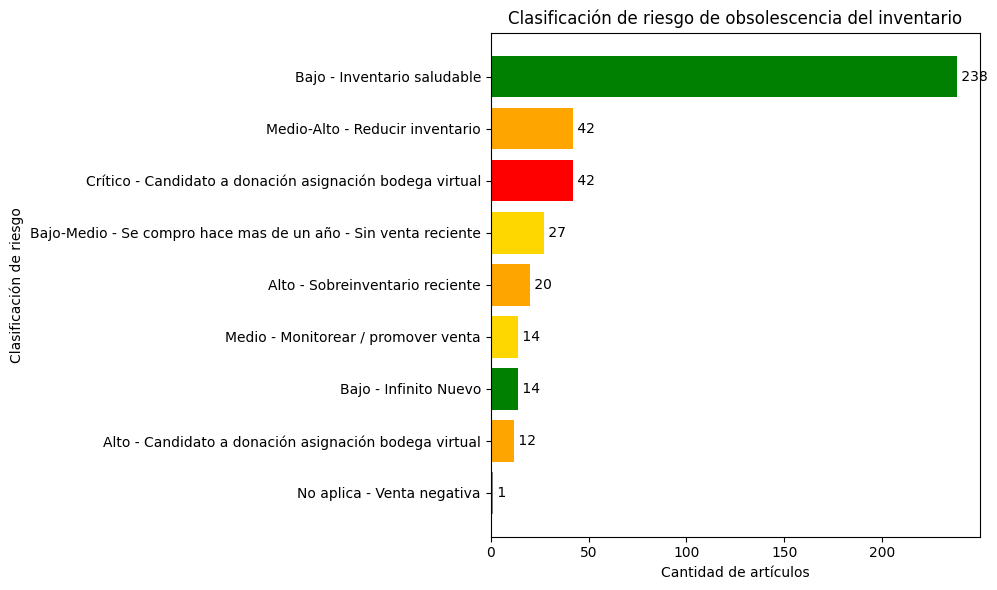

In [160]:
import matplotlib.pyplot as plt

# ============================================================
# CONTEO DE ARTÍCULOS POR CLASIFICACIÓN
# ============================================================

conteo_riesgo = (
    df["Riesgo_Obsolescencia"]
    .value_counts()
    .sort_values(ascending=True)
)

# ============================================================
# FUNCIÓN PARA ASIGNAR COLOR SEGÚN RIESGO
# ============================================================

def asignar_color_riesgo(clasificacion):
    
    if "Crítico" in clasificacion:
        return "red"
    
    elif "Alto" in clasificacion:
        return "orange"
    
    elif "Medio" in clasificacion:
        return "gold"
    
    elif "Bajo" in clasificacion:
        return "green"
    
    else:
        return "gray"


colores = [asignar_color_riesgo(riesgo) for riesgo in conteo_riesgo.index]

# ============================================================
# GRÁFICO DE BARRAS HORIZONTAL
# ============================================================

plt.figure(figsize=(10, 6))

plt.barh(
    conteo_riesgo.index,
    conteo_riesgo.values,
    color=colores
)

plt.title("Clasificación de riesgo de obsolescencia del inventario")
plt.xlabel("Cantidad de artículos")
plt.ylabel("Clasificación de riesgo")

# Agregar etiquetas al final de cada barra
for i, valor in enumerate(conteo_riesgo.values):
    plt.text(
        valor,
        i,
        f" {valor}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [161]:
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import PatternFill

# ============================================================
# EXPORTAR DATAFRAME A EXCEL
# ============================================================

ruta_excel = "inventario_riesgo_obsolescencia.xlsx"

df.to_excel(ruta_excel, index=False, sheet_name="Inventario")

# ============================================================
# ABRIR EXCEL
# ============================================================

wb = load_workbook(ruta_excel)
ws = wb["Inventario"]

# ============================================================
# DEFINIR COLORES
# ============================================================

fill_bajo = PatternFill(start_color="C6EFCE", end_color="C6EFCE", fill_type="solid")
fill_medio = PatternFill(start_color="FFEB9C", end_color="FFEB9C", fill_type="solid")
fill_alto = PatternFill(start_color="F4B183", end_color="F4B183", fill_type="solid")
fill_critico = PatternFill(start_color="FF0000", end_color="FF0000", fill_type="solid")
fill_no_aplica = PatternFill(start_color="D9EAD3", end_color="D9EAD3", fill_type="solid")
fill_revision = PatternFill(start_color="D9D9D9", end_color="D9D9D9", fill_type="solid")

# ============================================================
# FUNCIÓN DE COLOR
# ============================================================

def asignar_fill_riesgo(clasificacion):
    
    clasificacion = str(clasificacion)
    
    if "Crítico" in clasificacion:
        return fill_critico
    
    elif "Alto" in clasificacion:
        return fill_alto
    
    elif "Medio" in clasificacion:
        return fill_medio
    
    elif "Bajo" in clasificacion:
        return fill_bajo
    
    elif "No aplica" in clasificacion:
        return fill_no_aplica
    
    else:
        return fill_revision

# ============================================================
# IDENTIFICAR COLUMNA RIESGO_OBSOLESCENCIA
# ============================================================

headers = [cell.value for cell in ws[1]]
col_riesgo = headers.index("Riesgo_Obsolescencia") + 1

# ============================================================
# PINTAR FILAS
# ============================================================

for row in range(2, ws.max_row + 1):
    
    clasificacion = ws.cell(row=row, column=col_riesgo).value
    fill = asignar_fill_riesgo(clasificacion)
    
    for col in range(1, ws.max_column + 1):
        ws.cell(row=row, column=col).fill = fill

# ============================================================
# GUARDAR EXCEL
# ============================================================

wb.save(ruta_excel)